  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:05<00:00, 388.33it/s]


Optimized hyperparameters: l=2.651, sigma_f=178.534


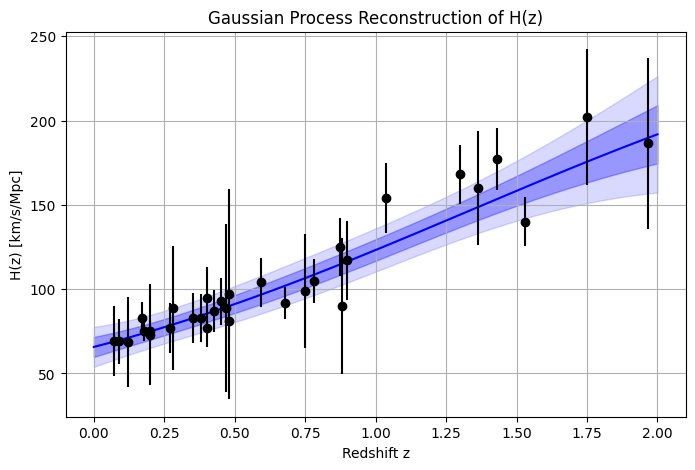

In [ ]:
from gauss import GPR
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
data = np.loadtxt('data/cc.txt')
z_obs = data[:, 0]
H_obs = data[:, 1]
Cov_data = np.loadtxt('data/cc_cov.txt')
gpr = GPR(l=1.0, sigma_f=100, kernel_name='rbf') 
gpr.fit(z_obs, H_obs, Cov_data, optimize_method='emcee') 
print(f"Optimized hyperparameters: l={gpr.l:.3f}, sigma_f={gpr.sigma_f:.3f}")
z_pred = np.linspace(0, 2, 200)
mu_pred, cov_pred = gpr.predict_with_uncertainty(z_pred)
std_pred = np.sqrt(np.diag(cov_pred))
plt.figure(figsize=(8,5))
plt.fill_between(z_pred, mu_pred -  std_pred, mu_pred + std_pred, alpha=0.3, color='b')
plt.fill_between(z_pred, mu_pred -  2*std_pred, mu_pred + 2*std_pred, alpha=0.15, color='b')
plt.plot(z_pred, mu_pred, color='blue')
plt.errorbar(z_obs,H_obs , yerr=np.sqrt(np.diag(Cov_data)), fmt='o', color ='black')
plt.xlabel('Redshift z')
plt.ylabel('H(z) [km/s/Mpc]')
plt.title('Gaussian Process Reconstruction of H(z)')
plt.grid(True)
plt.show()

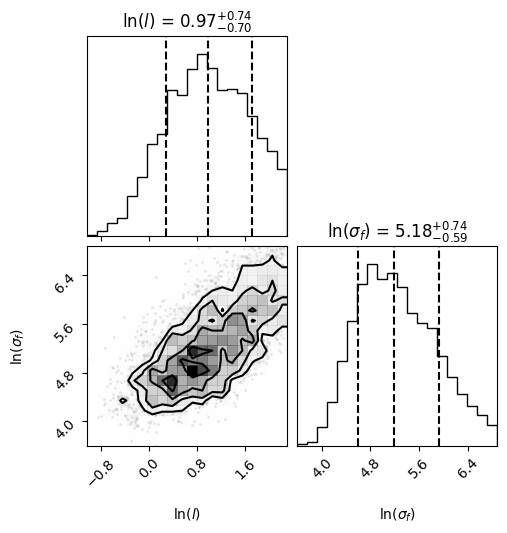

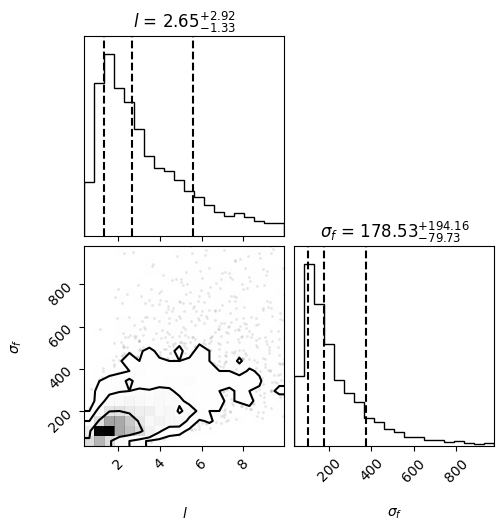

In [4]:
import corner
fig = corner.corner(gpr.hyperparameter_samples, labels=[r"$\ln(l)$", r"$\ln(\sigma_f)$"], quantiles=[0.16, 0.5, 0.84], show_titles=True)
fig = corner.corner(np.exp(gpr.hyperparameter_samples), labels=[r"$l$", r"$\sigma_f$"], quantiles=[0.16, 0.5, 0.84], show_titles=True)

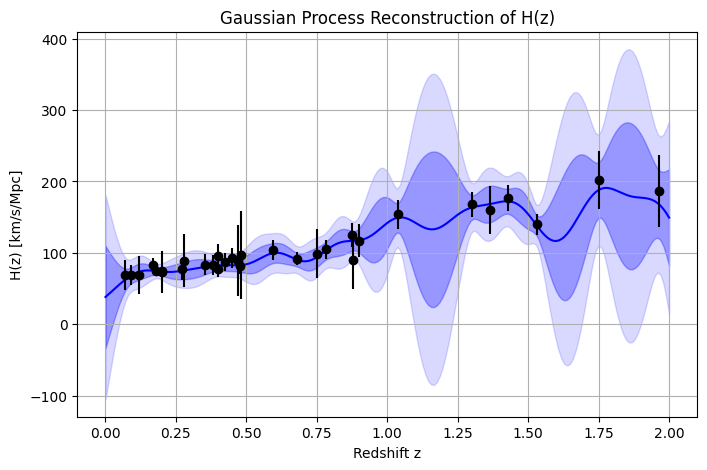

In [8]:
mu_pred, cov_pred = gpr._predict_single_theta(z_pred,0.1,150,2.5)
std_pred = np.sqrt(np.diag(cov_pred))
plt.figure(figsize=(8,5))
plt.fill_between(z_pred, mu_pred -  std_pred, mu_pred + std_pred, alpha=0.3, color='b')
plt.fill_between(z_pred, mu_pred -  2*std_pred, mu_pred + 2*std_pred, alpha=0.15, color='b')
plt.plot(z_pred, mu_pred, color='blue')
plt.errorbar(z_obs,H_obs , yerr=np.sqrt(np.diag(Cov_data)), fmt='o', color ='black')
plt.xlabel('Redshift z')
plt.ylabel('H(z) [km/s/Mpc]')
plt.title('Gaussian Process Reconstruction of H(z)')
plt.grid(True)
plt.show()

In [6]:
Cov_data.shape

(1701, 1701)

Optimized hyperparameters: l=5.929, sigma_f=53.027


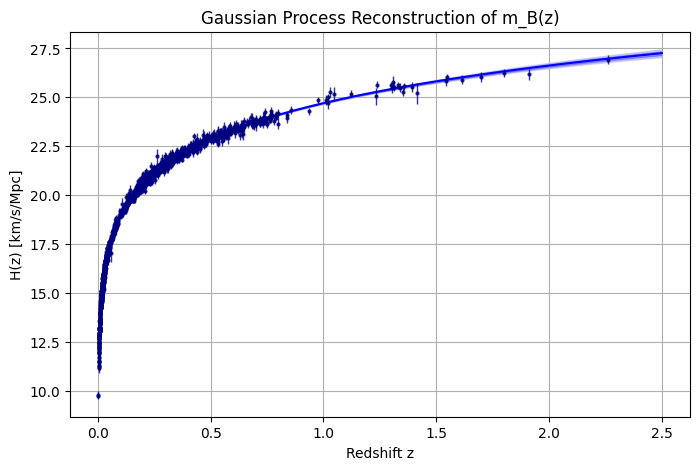

In [1]:
from gauss import GPR
import numpy as np
import matplotlib.pyplot as plt
import utils
import pandas as pd
np.random.seed(42)
sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
mB_obs = sn_df['m_b_corr'].values
Cov_data = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")
gpr = GPR(l=1.0, sigma_f=100, kernel_name='rbf') 
gpr.fit(np.log(z_sn), mB_obs, np.diag(np.diag(Cov_data)), optimize_method='minimize') 
print(f"Optimized hyperparameters: l={gpr.l:.3f}, sigma_f={gpr.sigma_f:.3f}")
z_pred = np.linspace(0.05, 2.5, 200)
mu_pred, cov_pred = gpr.predict(np.log(z_pred))
std_pred = np.sqrt(np.diag(cov_pred))
plt.figure(figsize=(8,5))
plt.fill_between(z_pred, mu_pred -  std_pred, mu_pred + std_pred, alpha=0.3, color='b')
plt.fill_between(z_pred, mu_pred -  2*std_pred, mu_pred + 2*std_pred, alpha=0.15, color='b')
plt.plot(z_pred, mu_pred, color='blue')
plt.errorbar(z_sn, mB_obs, yerr=np.sqrt(np.diag(Cov_data)),fmt='o', capsize=0, ms=2, elinewidth=1, color='navy', alpha=0.8)
plt.xlabel('Redshift z')
plt.ylabel('H(z) [km/s/Mpc]')
plt.title('Gaussian Process Reconstruction of m_B(z)')
plt.grid(True)
plt.show()

{'k1': 28.4**2, 'k2': RBF(length_scale=8.37), 'k1__constant_value': 806.4976145411671, 'k1__constant_value_bounds': (0.1, 10000.0), 'k2__length_scale': 8.3680261371041, 'k2__length_scale_bounds': (0.0001, 100.0)}


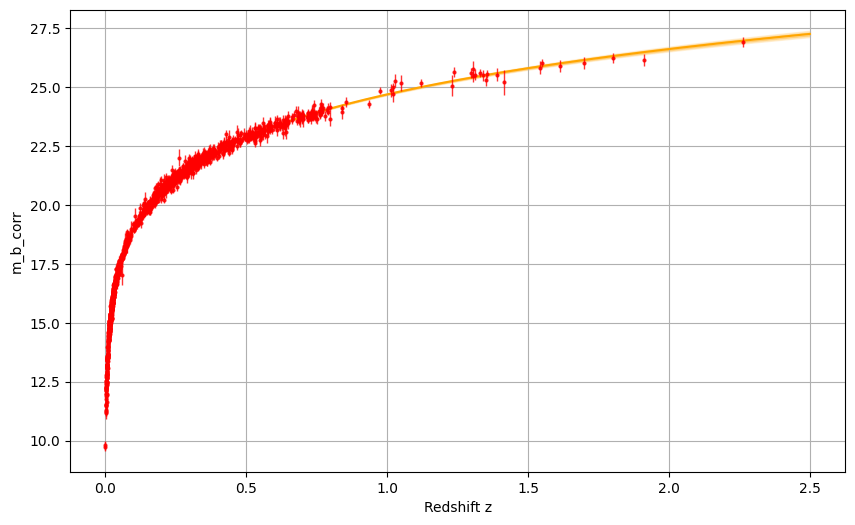

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

import utils

np.random.seed(42)
sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
mB_obs = sn_df['m_b_corr'].values
Cov_data_full = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")

X_train = np.log(z_sn).reshape(-1, 1)
y_train = mB_obs
noise_variances = np.diag(Cov_data_full)

kernel = C(1, (1e-1, 1e4)) * RBF(100.0, (1e-4, 1e2))
gpr_sk = GaussianProcessRegressor(kernel=kernel, alpha=noise_variances, n_restarts_optimizer=10, random_state=42)
gpr_sk.fit(X_train, y_train)
optimized = gpr_sk.kernel_.get_params()
print(optimized)

z_pred = np.linspace(0.05, 2.5, 200)
X_pred = np.log(z_pred).reshape(-1, 1)
mu_pred, std_pred = gpr_sk.predict(X_pred, return_std=True)

plt.figure(figsize=(10, 6))
plt.fill_between(z_pred, mu_pred - std_pred, mu_pred + std_pred, alpha=0.3, color='orange')
plt.fill_between(z_pred, mu_pred - 2 * std_pred, mu_pred + 2 * std_pred, alpha=0.15, color='orange')
plt.plot(z_pred, mu_pred, color='orange')
plt.errorbar(z_sn, mB_obs, yerr=np.sqrt(np.diag(Cov_data_full)),fmt='o', capsize=0, ms=2, elinewidth=1, color='red', alpha=0.8)
plt.xlabel('Redshift z')
plt.ylabel('m_b_corr')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
np.random.seed(42)
import utils

z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)
mask_dm, mask_dh = (bao_type == 'DM_over_rs'), (bao_type == 'DH_over_rs')
dm_rs, dh_rs = bao_val[mask_dm], bao_val[mask_dh]
z_bao = z_bao[mask_dh]

data = np.loadtxt('data/cc.txt')
z_cc = data[:, 0]
H_cc = data[:, 1]
cc_cov = np.loadtxt('data/cc_cov.txt')

sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
mB_obs = sn_df['m_b_corr'].values
mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")

In [ ]:
import numpy as np
import pandas as pd
import emcee
from scipy.interpolate import PchipInterpolator
from scipy.optimize import minimize
import utils

np.random.seed(42)

z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)
mask_dm, mask_dh = (bao_type == 'DM_over_rs'), (bao_type == 'DH_over_rs')
z_exclude_dv = z_bao[mask_dh] # BAO nodes

data = np.loadtxt('data/cc.txt')
z_cc, H_cc = data[:, 0], data[:, 1]
H_cov = np.loadtxt('data/cc_cov.txt')

# --- Configuration ---
z_knots = np.concatenate(([0.0], z_exclude_dv)) # [0.0, 0.38, ..., 2.33]
n_dim = len(z_knots)
inv_cc_cov = np.linalg.inv(H_cov)

# 计算一个宽松的 LCDM 理论值作为锚点
# H(z) ~ 70 * E(z)
hz_fiducial = 70.0 * np.sqrt(0.3 * (1 + z_knots)**3 + 0.7)

def log_prior(theta):
    # 1. 物理底线 A：H(z) 必须大于 0
    if np.any(theta <= 0): return -np.inf
    
    # 2. 物理底线 B：H(z) 必须单调递增 (Monotonicity)
    # np.diff 计算相邻元素的差值：[H1-H0, H2-H1, ...]
    # 我们要求所有差值都必须 > 0
    if np.any(np.diff(theta) <= 0):
        return -np.inf
    
    # --- 到了这里，物理上已经合理了，下面是针对外推点的平滑约束 ---
    
    # 3. 针对外推点 (z=2.33) 的平滑性约束
    # (之前的二阶导数/斜率约束仍然保留，防止最后一个点虽然增加了，但是直接飞到 H=10000)
    
    h_last = theta[-1]      # z=2.33
    h_prev = theta[-2]      # z=1.48
    h_prev2 = theta[-3]     # z=0.85
    
    z_last = z_knots[-1]
    z_prev = z_knots[-2]
    z_prev2 = z_knots[-3]
    
    slope_prev = (h_prev - h_prev2) / (z_prev - z_prev2)
    slope_curr = (h_last - h_prev) / (z_last - z_prev)
    
    # 限制斜率变化不要太剧烈 (Soft constraint)
    delta_slope = slope_curr - slope_prev
    sigma_slope = 1.0 * np.abs(slope_prev) + 5.0 # 稍微收紧一点 sigma
    
    lp = -0.5 * (delta_slope / sigma_slope)**2
    
    return lp

def log_likelihood(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp): return -np.inf
    
    # PCHIP 插值
    interp = PchipInterpolator(z_knots, theta)
    model_h = interp(z_cc)
    
    # Chi2 计算
    diff = model_h - H_cc
    chi2 = diff @ inv_cc_cov @ diff
    return -0.5 * chi2 + lp

# --- MCMC Setup ---
n_walkers = 32
n_steps = 6000 # 外推需要跑久一点让它收敛
burn_in = 1000

# 初始位置在 Fiducial 附近扰动
p0 = hz_fiducial + 5.0 * np.random.randn(n_walkers, n_dim)

print("Running MCMC ...")
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_likelihood)
sampler.run_mcmc(p0, n_steps, progress=True)

# --- Process ---
flat_samples = sampler.get_chain(discard=burn_in, flat=True)
# 只要 BAO 节点 (去掉 z=0)
h_bao_samples = flat_samples[:, 1:] 

hz_mean = np.mean(h_bao_samples, axis=0)
hz_cov = np.cov(h_bao_samples, rowvar=False)

print("\nResult at z=2.33 (Last Node):")
print(f"Mean: {hz_mean[-1]:.2f}, Err: {np.sqrt(hz_cov[-1,-1]):.2f}")
print(f"Fiducial LCDM was: {hz_fiducial[-1]:.2f}")
print(sampler.get_autocorr_time())


Running MCMC ...


  0%|          | 0/6000 [00:00<?, ?it/s]

100%|██████████| 6000/6000 [00:19<00:00, 308.00it/s]



Result at z=2.33 (Last Node):
Mean: 294.45, Err: 96.88
Fiducial LCDM was: 240.23
[115.81208635 105.35887947 112.07503737 107.84301305 108.78493318
 104.62177041 107.40985143]


<ErrorbarContainer object of 3 artists>

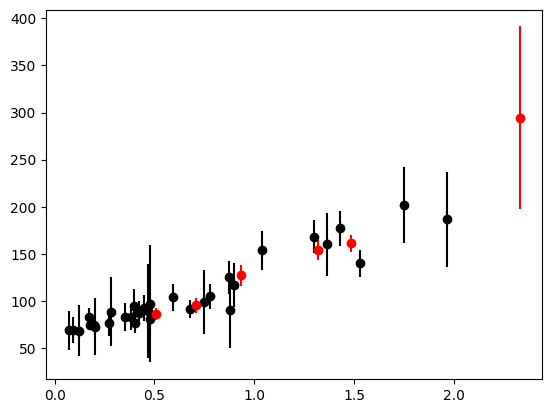

In [82]:
plt.errorbar(z_cc, H_cc, yerr=np.sqrt(np.diag(H_cov)), fmt='o', color ='black')
plt.errorbar(z_exclude_dv, hz_mean, yerr=np.sqrt(np.diag(hz_cov)), fmt='o', color ='red')

In [62]:
import numpy as np
import pandas as pd
import emcee
from scipy.interpolate import PchipInterpolator
from scipy.optimize import minimize
import utils

np.random.seed(42)

z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)
mask_dm, mask_dh = (bao_type == 'DM_over_rs'), (bao_type == 'DH_over_rs')
z_exclude_dv = z_bao[mask_dh] # BAO nodes

sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
mB_obs = sn_df['m_b_corr'].values
mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")
inv_mB_cov = np.linalg.inv(mB_cov)


z_knots = np.concatenate(([0.005], z_exclude_dv))
m_cp_init = np.interp(z_knots, z_sn, mB_obs)
res = minimize(lambda p: -utils.ln_posterior(p, z_sn, mB_obs, inv_mB_cov, z_knots), m_cp_init, method='L-BFGS-B')
print(res.x)

def log_likelihood(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp): return -np.inf
    
    # PCHIP 插值
    interp = PchipInterpolator(np.log(z_knots), theta)
    mB_model = interp(np.log(z_sn))
    
    # Chi2 计算
    diff = mB_model - mB_obs
    chi2 = diff @ inv_mB_cov @ diff
    return -0.5 * chi2# 加上先验

# --- MCMC Setup ---
n_walkers = 32
n_steps = 6000 # 外推需要跑久一点让它收敛
burn_in = 1000

# 初始位置在 Fiducial 附近扰动
p0 = res.x + 1e-4  * np.random.randn(n_walkers, n_dim)

print("Running MCMC ...")
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_likelihood)
sampler.run_mcmc(p0, n_steps, progress=True)

# --- Process ---
flat_samples = sampler.get_chain(discard=burn_in, flat=True)
# 只要 BAO 节点 (去掉 z=0)
mB_bao_samples = flat_samples[:, 1:] 

mB_mean_knots = np.mean(mB_bao_samples, axis=0)
mB_cov_knots = np.cov(mB_bao_samples, rowvar=False)

print(sampler.get_autocorr_time())


[12.16310644 22.79025215 23.74874163 24.49785909 25.6255528  25.73155605
 26.86836273]
Running MCMC ...


100%|██████████| 6000/6000 [01:46<00:00, 56.13it/s]


[95.58817723 70.32389054 63.92581061 90.99482696 60.81556825 70.08040585
 85.28226769]


In [63]:
mB_mean_knots

array([22.88785609, 23.73392103, 24.56100383, 25.63767035, 25.80264768,
       27.0306915 ])

<ErrorbarContainer object of 3 artists>

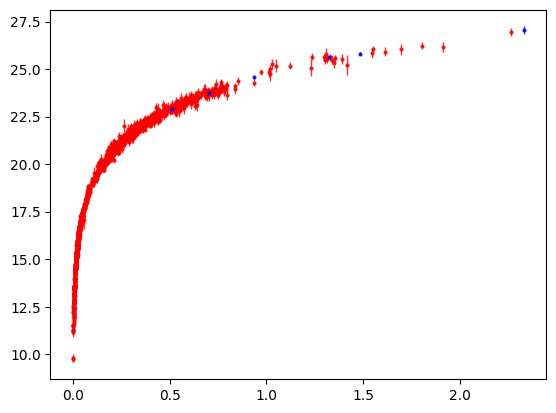

In [64]:
plt.errorbar(z_sn, mB_obs, yerr=np.sqrt(np.diag(Cov_data_full)),fmt='o', capsize=0, ms=2, elinewidth=1, color='red', alpha=0.8)
plt.errorbar(z_exclude_dv, mB_mean_knots, yerr=np.sqrt(np.diag(mB_cov_knots)),fmt='o', capsize=0, ms=2, elinewidth=1, color='blue', alpha=0.8)